In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# Importar datos 

In [2]:
df_riesgo = pd.read_csv('german_credit_data.csv')

In [3]:
df_riesgo.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [4]:
df_riesgo=df_riesgo.drop(columns=['Unnamed: 0'])

In [5]:
df_riesgo.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [6]:
df_riesgo.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [7]:
df_riesgo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [8]:
df_riesgo.dtypes

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

In [9]:
#### funcion vatiable de riesgo

np.random.seed(42)

def crear_variable_riesgo(row):
    score = 0
    
    if row['Age'] < 25 or row['Age'] > 60:
        score += 1
    if pd.isna(row['Saving accounts']) or row['Saving accounts'] == 'little':
        score += 1
    if pd.isna(row['Checking account']) or row['Checking account'] == 'little':
        score += 1
    if row['Credit amount'] > df_riesgo['Credit amount'].quantile(0.75):
        score += 1
    if row['Duration'] > 36:
        score += 1
    if row['Job'] == 0:
        score += 1
    
    if score >= 3:
        return 'bad' if np.random.random() > 0.2 else 'good'
    elif score <= 1:
        return 'good' if np.random.random() > 0.2 else 'bad'
    else:
        return 'good' if np.random.random() > 0.4 else 'bad'

In [10]:
df_riesgo['riesgo']=df_riesgo.apply(crear_variable_riesgo,axis=1)


In [11]:
df_riesgo.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,riesgo
0,67,male,2,own,NaN,little,1169,6,radio/TV,bad
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,bad
4,53,male,2,free,little,little,4870,24,car,good


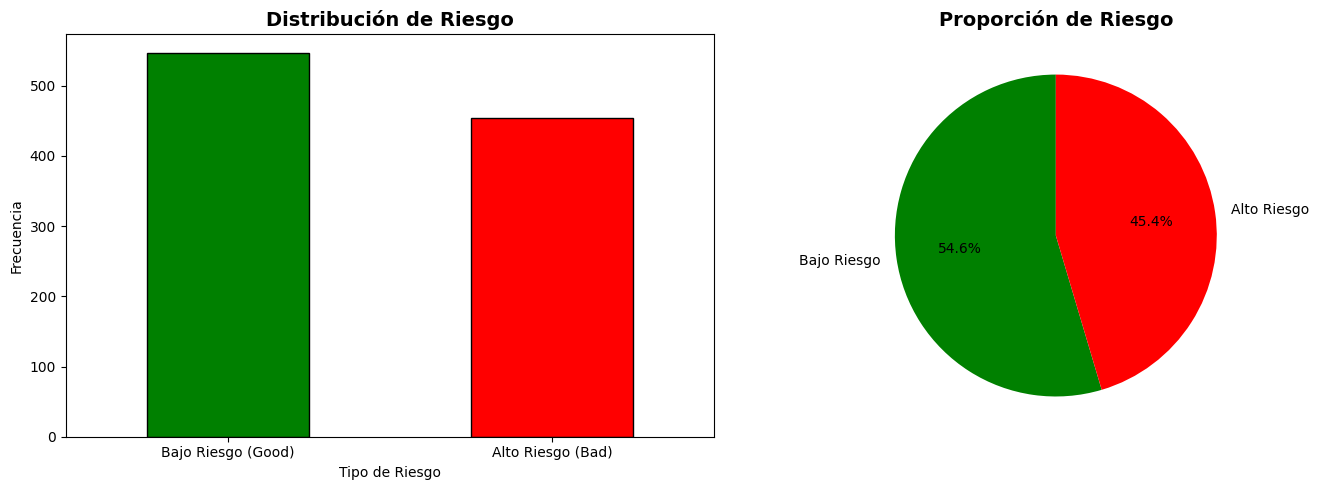

In [12]:
# Visualizar distribución del target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
df_riesgo['riesgo'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'], edgecolor='black')
axes[0].set_title('Distribución de Riesgo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de Riesgo')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['Bajo Riesgo (Good)', 'Alto Riesgo (Bad)'], rotation=0)

# Gráfico de pastel
axes[1].pie(df_riesgo['riesgo'].value_counts(), labels=['Bajo Riesgo', 'Alto Riesgo'],
            autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Proporción de Riesgo', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
df_riesgo['Saving accounts'].value_counts()

Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [14]:
df_riesgo['Checking account'].value_counts()

Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64

## Limpieza de datos

In [15]:
### imputacion de datos 

df_riesgo_clean= df_riesgo.copy()
df_riesgo_clean['Saving accounts']=df_riesgo_clean['Saving accounts'].fillna('No_savings')
df_riesgo_clean['Checking account']=df_riesgo_clean['Checking account'].fillna('No_checking')
df_riesgo_clean.isnull().sum()


Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
riesgo              0
dtype: int64

## Ingenieria de caracteristicas

In [16]:
df_ic=df_riesgo_clean.copy()

In [17]:
## Generar el pago mensual estimado

df_ic['Pago_mensual']=df_ic['Credit amount']/df_ic['Duration']

In [18]:
#### Identificar si es Joven, adulta, etc segun edad 

def cate_edad(Age):
    if Age < 25:
        return 'Joven'
    elif Age < 40:
        return 'Adulto'
    elif Age < 60:
        return 'Tercera_edad'
    else: 
        return 'Alduto_Mayor'

In [19]:
## crear categoria edad 

df_ic['Categoria_edad']=df_ic['Age'].apply(cate_edad)

In [20]:
## esto es equivalente a aplicar la distribucion 

df_ic['Credit_category'] = pd.cut(df_ic['Credit amount'],
                                   bins=[0, 2000, 5000, 10000, float('inf')],
                                   labels=['low', 'medium', 'high', 'very_high'])

In [21]:
def calculate_financial_score(row):
    score = 0
    if row['Saving accounts'] == 'rich':
        score += 3
    elif row['Saving accounts'] == 'quite rich':
        score += 2
    elif row['Saving accounts'] == 'moderate':
        score += 1
    elif row['Saving accounts'] == 'little':
        score += 0.5
    
    if row['Checking account'] == 'rich':
        score += 2
    elif row['Checking account'] == 'moderate':
        score += 1
    elif row['Checking account'] == 'little':
        score += 0.5
    
    if row['Housing'] == 'own':
        score += 2
    elif row['Housing'] == 'free':
        score += 1
    
    score += row['Job']
    return score

In [22]:
df_ic['Salud_financiera']=df_ic.apply(calculate_financial_score,axis=1)

In [23]:
df_ic.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,riesgo,Pago_mensual,Categoria_edad,Credit_category,Salud_financiera
0,67,male,2,own,No_savings,little,1169,6,radio/TV,bad,194.833333,Alduto_Mayor,low,4.5
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,123.979167,Joven,high,5.5
2,49,male,1,own,little,No_checking,2096,12,education,good,174.666667,Tercera_edad,medium,3.5
3,45,male,2,free,little,little,7882,42,furniture/equipment,bad,187.666667,Tercera_edad,high,4.0
4,53,male,2,free,little,little,4870,24,car,good,202.916667,Tercera_edad,medium,4.0


In [24]:
### indicador binario para cuenta de ahorros y corriente 

df_ic['no_cah']=(df_ic['Saving accounts']=='No_savings').astype(int)
df_ic['no_ccorr']=(df_ic['Checking account']=='No_checking').astype(int)

In [25]:
df_ic.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,riesgo,Pago_mensual,Categoria_edad,Credit_category,Salud_financiera,no_cah,no_ccorr
0,67,male,2,own,No_savings,little,1169,6,radio/TV,bad,194.833333,Alduto_Mayor,low,4.5,1,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,123.979167,Joven,high,5.5,0,0
2,49,male,1,own,little,No_checking,2096,12,education,good,174.666667,Tercera_edad,medium,3.5,0,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,bad,187.666667,Tercera_edad,high,4.0,0,0
4,53,male,2,free,little,little,4870,24,car,good,202.916667,Tercera_edad,medium,4.0,0,0


In [26]:
#### tarea eliminar columnas y crear las variables dummies

In [27]:
df_ic.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'riesgo', 'Pago_mensual',
       'Categoria_edad', 'Credit_category', 'Salud_financiera', 'no_cah',
       'no_ccorr'],
      dtype='object')

In [28]:
columnasEliminar = ['Checking account',
'Saving accounts', 
'Job', 
'Housing']

df_ic=df_ic.drop(columns=columnasEliminar)

In [29]:
df_ic.head()

,Age,Sex,Credit amount,Duration,Purpose,riesgo,Pago_mensual,Categoria_edad,Credit_category,Salud_financiera,no_cah,no_ccorr
0,67,male,1169,6,radio/TV,bad,194.833333,Alduto_Mayor,low,4.5,1,0
1,22,female,5951,48,radio/TV,bad,123.979167,Joven,high,5.5,0,0
2,49,male,2096,12,education,good,174.666667,Tercera_edad,medium,3.5,0,1
3,45,male,7882,42,furniture/equipment,bad,187.666667,Tercera_edad,high,4.0,0,0
4,53,male,4870,24,car,good,202.916667,Tercera_edad,medium,4.0,0,0


In [30]:
df_ic.columns

Index(['Age', 'Sex', 'Credit amount', 'Duration', 'Purpose', 'riesgo',
       'Pago_mensual', 'Categoria_edad', 'Credit_category', 'Salud_financiera',
       'no_cah', 'no_ccorr'],
      dtype='object')

In [31]:
columnasCategoricas=['Sex',
'Purpose', 
'riesgo',
'Categoria_edad',
'Credit_category'
]

columnasNumericas=['Age',
'Credit amount',
'Duration',
'Salud_financiera',
'no_cah',
'no_ccorr'
]

features_all = ['Age',
'Credit amount',
'Duration',
'Salud_financiera',
'no_cah',
'no_ccorr',
'Sex',
'Purpose', 
'Categoria_edad',
'Credit_category'
]

In [32]:
df_model=df_ic[features_all+['riesgo']].copy()

In [33]:
cat_features=df_model.select_dtypes(include=['object','category']).columns.tolist()

In [34]:
df_model.dtypes

Age                    int64
Credit amount          int64
Duration               int64
Salud_financiera     float64
no_cah                 int32
no_ccorr               int32
Sex                   object
Purpose               object
Categoria_edad        object
Credit_category     category
riesgo                object
dtype: object

In [35]:
cat_features.remove('riesgo')

In [36]:
# One-Hot Encoding

df_encoded=pd.get_dummies(df_model,columns=cat_features,drop_first=True,dtype=int)

In [37]:
df_encoded.dtypes

Age                              int64
Credit amount                    int64
Duration                         int64
Salud_financiera               float64
no_cah                           int32
no_ccorr                         int32
riesgo                          object
Sex_male                         int32
Purpose_car                      int32
Purpose_domestic appliances      int32
Purpose_education                int32
Purpose_furniture/equipment      int32
Purpose_radio/TV                 int32
Purpose_repairs                  int32
Purpose_vacation/others          int32
Categoria_edad_Alduto_Mayor      int32
Categoria_edad_Joven             int32
Categoria_edad_Tercera_edad      int32
Credit_category_medium           int32
Credit_category_high             int32
Credit_category_very_high        int32
dtype: object

In [38]:
df_encoded.columns

Index(['Age', 'Credit amount', 'Duration', 'Salud_financiera', 'no_cah',
       'no_ccorr', 'riesgo', 'Sex_male', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others', 'Categoria_edad_Alduto_Mayor',
       'Categoria_edad_Joven', 'Categoria_edad_Tercera_edad',
       'Credit_category_medium', 'Credit_category_high',
       'Credit_category_very_high'],
      dtype='object')

# Modelación

In [39]:
## identificar cuando el cliente esta en riesgo
## solo se entrena el modelo con la informacion de personas riesgo malo
## siempre en modelos la X es mayuscula

y=(df_encoded['riesgo']=='bad').astype(int)
X=df_encoded.drop(columns='riesgo')


In [40]:
from sklearn.model_selection import train_test_split 


In [41]:
### dividir en 80-20 entrenamiento y prueba

test_size=0.2
random_state=42

# División
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)

In [42]:
X_train

,Age,Credit amount,Duration,Salud_financiera,no_cah,no_ccorr,Sex_male,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Categoria_edad_Alduto_Mayor,Categoria_edad_Joven,Categoria_edad_Tercera_edad,Credit_category_medium,Credit_category_high,Credit_category_very_high
29,63,6836,60,5.0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
535,33,2319,21,4.5,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0
695,50,1236,6,4.0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0
557,29,5003,21,4.0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0
836,21,886,12,4.0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,39,6458,18,5.5,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0
270,32,2662,18,4.0,1,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0
860,27,5804,24,7.0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0
435,25,1484,12,5.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0


In [43]:
import statsmodels.api as sm 
from scipy import stats

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

In [45]:
# Normalizar para Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Diccionario para almacenar resultados
resultados = []

# Modelo 1

In [46]:
# MODELO 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

resultados.append({
    'Modelo': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr)
})

In [47]:
print(resultados)

[{'Modelo': 'Logistic Regression', 'Accuracy': 0.65, 'Precision': 0.6231884057971014, 'Recall': 0.4942528735632184, 'F1': 0.5512820512820513, 'ROC-AUC': 0.6887397009459871}]


In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [49]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()

Text(0.5, 1.0, 'Matriz de Confusión - Logistic Regression')

<Figure size 1000x800 with 0 Axes>

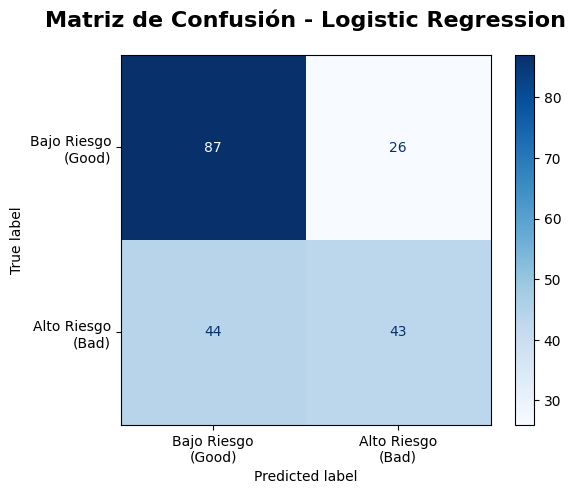

In [50]:
# Crear figura
plt.figure(figsize=(10, 8))

# Visualizar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Bajo Riesgo\n(Good)', 'Alto Riesgo\n(Bad)']
)
disp.plot(cmap='Blues', values_format='d', colorbar=True)

plt.title('Matriz de Confusión - Logistic Regression', 
          fontsize=16, fontweight='bold', pad=20)

# Modelo 2

In [51]:
# MODELO 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

resultados.append({
    'Modelo': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
})

In [52]:
print(resultados)

[{'Modelo': 'Logistic Regression', 'Accuracy': 0.65, 'Precision': 0.6231884057971014, 'Recall': 0.4942528735632184, 'F1': 0.5512820512820513, 'ROC-AUC': 0.6887397009459871}, {'Modelo': 'Random Forest', 'Accuracy': 0.645, 'Precision': 0.6111111111111112, 'Recall': 0.5057471264367817, 'F1': 0.5534591194968553, 'ROC-AUC': 0.6809073339436478}]


In [53]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

Text(0.5, 1.0, 'Matriz de Confusión - Random Forest')

<Figure size 1000x800 with 0 Axes>

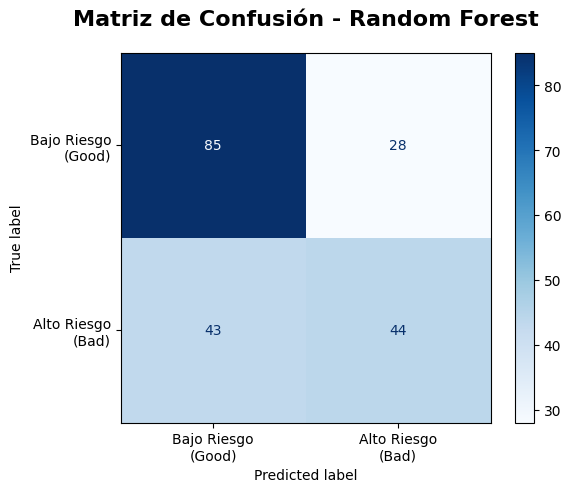

In [54]:
# Crear figura
plt.figure(figsize=(10, 8))

# Visualizar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Bajo Riesgo\n(Good)', 'Alto Riesgo\n(Bad)']
)
disp.plot(cmap='Blues', values_format='d', colorbar=True)

plt.title('Matriz de Confusión - Random Forest', 
          fontsize=16, fontweight='bold', pad=20)

# Modelo 3

In [55]:
# MODELO 3: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

resultados.append({
    'Modelo': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_gb)
})

In [56]:
print(resultados)


[{'Modelo': 'Logistic Regression', 'Accuracy': 0.65, 'Precision': 0.6231884057971014, 'Recall': 0.4942528735632184, 'F1': 0.5512820512820513, 'ROC-AUC': 0.6887397009459871}, {'Modelo': 'Random Forest', 'Accuracy': 0.645, 'Precision': 0.6111111111111112, 'Recall': 0.5057471264367817, 'F1': 0.5534591194968553, 'ROC-AUC': 0.6809073339436478}, {'Modelo': 'Gradient Boosting', 'Accuracy': 0.61, 'Precision': 0.56, 'Recall': 0.4827586206896552, 'F1': 0.5185185185185185, 'ROC-AUC': 0.6377784559047911}]


In [57]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb)
tn, fp, fn, tp = cm.ravel()

Text(0.5, 1.0, 'Matriz de Confusión - Gradient Boosting')

<Figure size 1000x800 with 0 Axes>

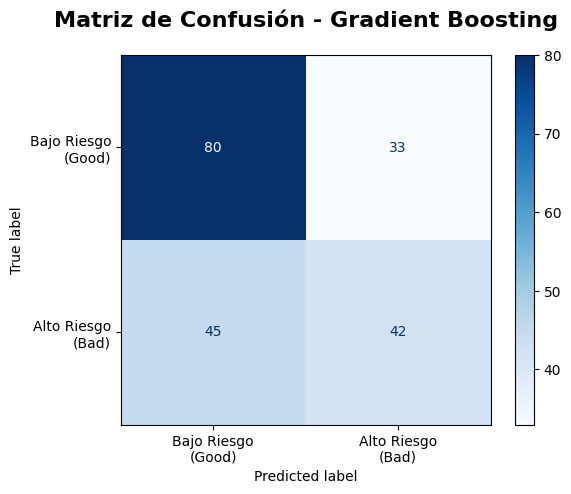

In [58]:
# Crear figura
plt.figure(figsize=(10, 8))

# Visualizar matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Bajo Riesgo\n(Good)', 'Alto Riesgo\n(Bad)']
)
disp.plot(cmap='Blues', values_format='d', colorbar=True)

plt.title('Matriz de Confusión - Gradient Boosting', 
          fontsize=16, fontweight='bold', pad=20)

# Modelo por Pycaret

In [59]:
###pip install pycaret

In [60]:
from pycaret.classification import *

In [61]:
##implementacion Smote

# Setup automático
clf = setup(
    data=df_encoded,                      # Dataset completo
    target='riesgo',                   # Variable objetivo
    session_id=42,                   # Semilla para reproducibilidad
    
    # Configuración de datos
    train_size=0.75,                 # 75% entrenamiento
    fix_imbalance=True,              # ✅ SMOTE automático
    fix_imbalance_method='smote',    # Método de balanceo
    
    # Preprocesamiento automático
    normalize=True,                  # Normalización automática
    transformation=True,             # Transformaciones automáticas
    remove_multicollinearity=True,   # Eliminar multicolinealidad
    multicollinearity_threshold=0.9, # Umbral
    
    # Feature engineering automático
    polynomial_features=True,        # Crear features polinómicas
    polynomial_degree=2,             # Grado 2 (x², x*y)
    ###feature_interaction=True,        # Interacciones entre features
    #####feature_ratio=True,              # Crear ratios automáticos
    
    # Validación
    fold=5,                          # Cross-validation 5-fold
    fold_strategy='stratifiedkfold', # Mantener proporción de clases
    
    # Configuración general
    ####silent=True,                     # No mostrar warnings
    verbose=True,                   # Modo silencioso
    ###html=False,                      # No generar HTML
    log_experiment=False             # No guardar experimento
)

,Description,Value
0,Session id,42
1,Target,riesgo
2,Target type,Binary
3,Target mapping,"bad: 0, good: 1"
4,Original data shape,"(1000, 21)"
5,Transformed data shape,"(1070, 169)"
6,Transformed train set shape,"(820, 169)"
7,Transformed test set shape,"(250, 169)"
8,Numeric features,20
9,Preprocess,True


In [62]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.6733,0.6981,0.6733,0.6728,0.6716,0.3368,0.3384,1.1100
gbc,Gradient Boosting Classifier,0.6600,0.6917,0.6600,0.6591,0.6567,0.3066,0.3094,0.5320
rf,Random Forest Classifier,0.6573,0.7002,0.6573,0.6560,0.6555,0.3039,0.3049,0.4820
lightgbm,Light Gradient Boosting Machine,0.6493,0.6793,0.6493,0.6477,0.6478,0.2882,0.2887,0.4640
ada,Ada Boost Classifier,0.6387,0.6712,0.6387,0.6377,0.6368,0.2666,0.2678,0.4280
et,Extra Trees Classifier,0.6387,0.6824,0.6387,0.6384,0.6367,0.2669,0.2687,0.3680
lr,Logistic Regression,0.6347,0.6656,0.6347,0.6327,0.6322,0.2565,0.2577,1.6160
ridge,Ridge Classifier,0.6347,0.6653,0.6347,0.6321,0.6314,0.2551,0.2564,0.3360
lda,Linear Discriminant Analysis,0.6293,0.6605,0.6293,0.6269,0.6248,0.2421,0.2447,0.2640
qda,Quadratic Discriminant Analysis,0.6133,0.6615,0.6133,0.6465,0.5624,0.1747,0.2236,0.3660


In [65]:
rf_model=create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6800,0.7660,0.6800,0.6800,0.6800,0.3544,0.3544
1,0.5867,0.6321,0.5867,0.5848,0.5853,0.1619,0.1621
2,0.7267,0.7621,0.7267,0.7262,0.7248,0.4436,0.4457
3,0.6800,0.7131,0.6800,0.6787,0.6783,0.3495,0.3506
4,0.6133,0.6277,0.6133,0.6104,0.6091,0.2100,0.2119
Mean,0.6573,0.7002,0.6573,0.6560,0.6555,0.3039,0.3049
Std,0.0505,0.0604,0.0505,0.0513,0.0510,0.1031,0.1033


In [66]:
# Optimizar Random Forest
tuned_rf = tune_model(
    rf_model,
    optimize='AUC',        # Optimizar para AUC
    n_iter=30,             # 30 combinaciones
    fold=5,                # 5-fold cross-validation
    search_algorithm='random',
    search_library='scikit-learn'  # Búsqueda inteligente
)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,06:40:02
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7133,0.7642,0.7133,0.7140,0.7097,0.4135,0.4183
1,0.6200,0.6569,0.6200,0.6177,0.6175,0.2265,0.2276
2,0.7267,0.7695,0.7267,0.7269,0.7241,0.4422,0.4456
3,0.7133,0.7331,0.7133,0.7127,0.7114,0.4165,0.4184
4,0.6667,0.6768,0.6667,0.6708,0.6560,0.3102,0.3227
Mean,0.6880,0.7201,0.6880,0.6884,0.6838,0.3618,0.3665
Std,0.0396,0.0457,0.0396,0.0401,0.0406,0.0814,0.0811


Fitting 5 folds for each of 30 candidates, totalling 150 fits


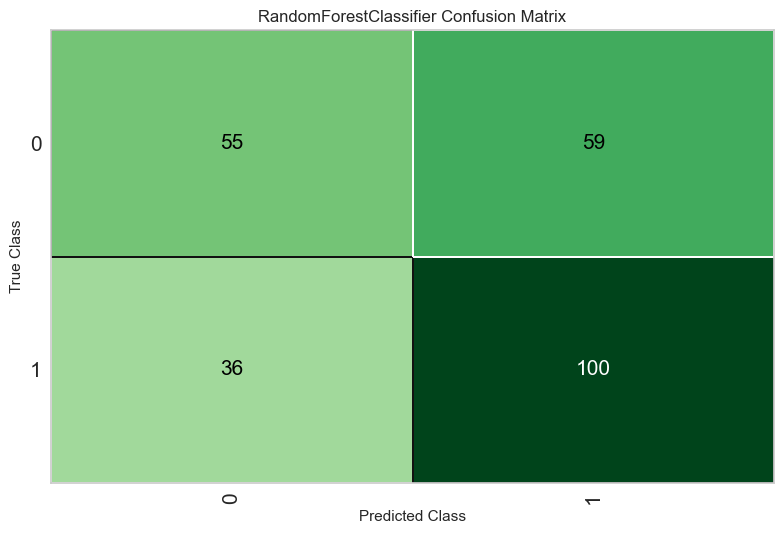

In [67]:
plot_model(tuned_rf,'confusion_matrix')

# Importancia de las caracteristicas

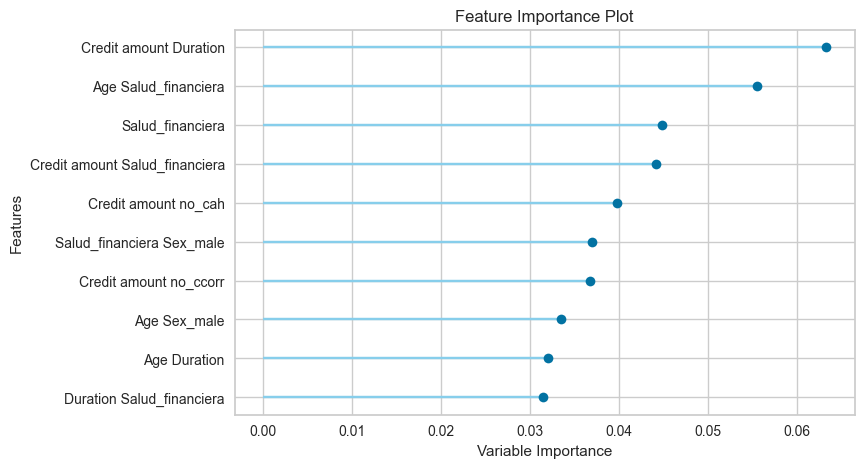

In [68]:
plot_model(tuned_rf,plot='feature')

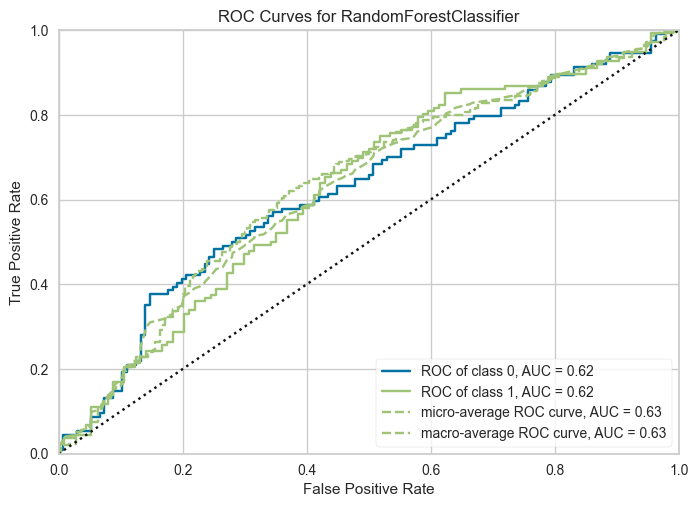

In [69]:
plot_model(tuned_rf,plot='auc')

# Generar predicciones 

In [70]:
predicciones=predict_model(tuned_rf)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.6200,0.6238,0.6200,0.6177,0.6135,0.2214,0.2254


In [71]:
predicciones.head()

,Age,Credit amount,Duration,Salud_financiera,no_cah,no_ccorr,Sex_male,Purpose_car,Purpose_domestic appliances,Purpose_education,...,Purpose_vacation/others,Categoria_edad_Alduto_Mayor,Categoria_edad_Joven,Categoria_edad_Tercera_edad,Credit_category_medium,Credit_category_high,Credit_category_very_high,riesgo,prediction_label,prediction_score
457,35,3386,12,4.0,0,0,1,1,0,0,...,0,0,0,0,1,0,0,good,good,0.5860
33,57,1264,12,1.0,1,1,1,0,0,0,...,0,0,0,1,0,0,0,good,bad,0.5467
822,41,2712,36,5.0,0,0,1,0,0,0,...,0,0,0,1,1,0,0,bad,good,0.6681
669,47,3017,30,6.5,0,0,1,0,0,0,...,0,0,0,1,1,0,0,good,good,0.6760
341,26,3599,21,2.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,good,bad,0.5816


In [72]:
predicciones_cols=predicciones[['prediction_label','prediction_score']]

In [73]:
df_completo= df_riesgo_clean.loc[predicciones_cols.index].copy()

In [74]:
df_completo['prediction_label']=predicciones_cols['prediction_label']

In [75]:
df_completo['prediction_score']=predicciones_cols['prediction_score']

In [76]:
df_completo.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,riesgo,prediction_label,prediction_score
457,35,male,2,free,little,little,3386,12,car,good,good,0.5860
33,57,male,1,rent,No_savings,No_checking,1264,12,business,good,bad,0.5467
822,41,male,2,own,little,little,2712,36,furniture/equipment,bad,good,0.6681
669,47,male,2,own,little,rich,3017,30,radio/TV,good,good,0.6760
341,26,female,1,rent,little,little,3599,21,furniture/equipment,good,bad,0.5816


In [77]:
df_completo.to_csv('PrediccionesCompletas_ModeloRiesgo.csv')

# Guardar modelo

In [78]:
from pycaret.classification import save_model

In [79]:
save_model(tuned_rf,'modelo_riesgo_credito')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age', 'Credit amount', 'Duration',
                                              'Salud_financiera', 'no_cah',
                                              'no_ccorr', 'Sex_male',
                                              'Purpose_car',
                                              'Purpose_domestic appliances',
                                              'Purpose_educat...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight={}, criterion='entropy',
                                         max_depth=9, max_features='sqrt',
                       